<a href="https://colab.research.google.com/github/tanvi1100/travel-hospitality-data-portfolio/blob/main/Booking_Funnel_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Create Funnel Dataset

In [1]:
import pandas as pd

funnel_data = {
    "stage": [
        "Search",
        "Hotel View",
        "Start Booking",
        "Completed Booking"
    ],
    "users": [
        1000,
        750,
        400,
        220
    ]
}

funnel_df = pd.DataFrame(funnel_data)

funnel_df

,stage,users
0,Search,1000
1,Hotel View,750
2,Start Booking,400
3,Completed Booking,220


##Calculate Conversion Rates

In [2]:
funnel_df["conversion_rate"] = (
    funnel_df["users"] /
    funnel_df["users"].iloc[0]
) * 100

funnel_df

,stage,users,conversion_rate
0,Search,1000,100.0
1,Hotel View,750,75.0
2,Start Booking,400,40.0
3,Completed Booking,220,22.0


##Calculate Drop-Offs

In [3]:
funnel_df["dropoff"] = (
    funnel_df["users"].shift(1)
    - funnel_df["users"]
)

funnel_df

,stage,users,conversion_rate,dropoff
0,Search,1000,100.0,NaN
1,Hotel View,750,75.0,250.0
2,Start Booking,400,40.0,350.0
3,Completed Booking,220,22.0,180.0


##Visualize Funnel

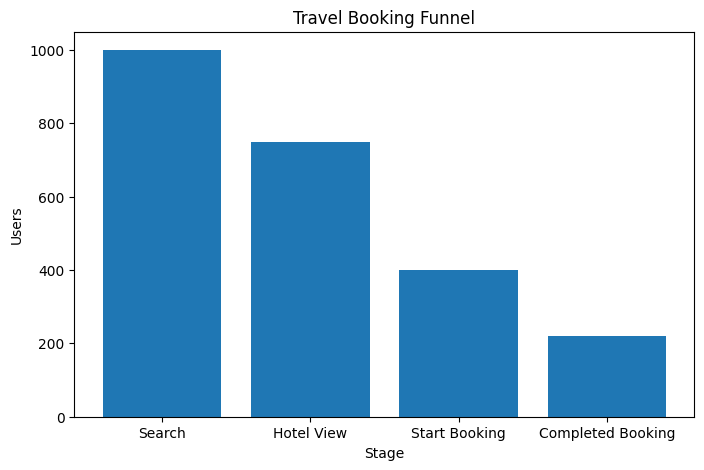

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    funnel_df["stage"],
    funnel_df["users"]
)

plt.title("Travel Booking Funnel")
plt.xlabel("Stage")
plt.ylabel("Users")

plt.show()

##Identify Biggest Drop-Off

In [5]:
dropoff_df = funnel_df.copy()

dropoff_df["dropoff"] = (
    dropoff_df["users"].shift(1)
    - dropoff_df["users"]
)

dropoff_df

,stage,users,conversion_rate,dropoff
0,Search,1000,100.0,NaN
1,Hotel View,750,75.0,250.0
2,Start Booking,400,40.0,350.0
3,Completed Booking,220,22.0,180.0


In [6]:
largest_drop = dropoff_df.loc[
    dropoff_df["dropoff"].idxmax()
]

largest_drop

,2
stage,Start Booking
users,400
conversion_rate,40.0
dropoff,350.0


##Business Interpretation

## Funnel Insights

- 1,000 users searched for hotels.
- 750 users viewed hotel details.
- 400 users started the booking process.
- 220 users completed a booking.

The largest drop-off occurred between Hotel View and Start Booking.

This may indicate:
- Pricing concerns
- Poor booking experience
- Limited hotel availability
- Additional fees shown during checkout

##Google AI Studio

## Booking Funnel Results

The booking funnel tracks how users move from hotel discovery to completed reservations.

Key metrics:

- Search → Hotel View: 75%
- Hotel View → Start Booking: 53.3%
- Start Booking → Completed Booking: 55%
- Overall Funnel Conversion: 22%

The largest drop-off occurred between Start Booking and Completed Booking, indicating potential checkout friction and revenue loss.

You are a Product Analyst at a travel booking company.

A booking funnel contains:

Search: 1000 users
Hotel View: 750 users
Start Booking: 400 users
Completed Booking: 220 users

Provide:

1. Executive summary
2. Funnel performance analysis
3. Revenue opportunities
4. Product recommendations
5. Future experimentation ideas

As a Product Analyst, I have analyzed our current booking funnel. While our initial engagement (Search to Hotel View) is strong, there is a significant **45% drop-off at the final checkout stage,** representing a major opportunity for conversion lift and revenue growth.
###1. Executive Summary
The funnel currently converts **22%** of searchers into confirmed bookings. While the top-of-funnel discovery phase is performing well (75% click-through to hotel pages), the **"Checkout Gap"**—where 180 users (45% of those who started booking) abandoned the process—is our primary area of concern. Closing this gap by even 10% would result in a **~9% increase in total revenue** without needing additional marketing spend.


###2. Funnel Performance Analysis

**Stage**	    **Users**	   **Step Conversion**	  **Total Conversion**	   **Drop-off Rate**

**Search**	        1,000	     -	                 100%	                -

**Hotel View**	     750	    **75%**	                 75%	               25%

**Start Booking**  	 400	    **53.3%**	               40%	               46.7%

**Completed**       220	    **55%**	                 **22%**             **45%**


**Discovery Phase (Search → View):** High efficiency (75%). This suggests that search results are relevant and filters are working effectively.

**Intent Phase (View → Start Booking):** A 46.7% drop-off here is normal for the industry, but often indicates "price shock" (taxes/fees) or a lack of immediate urgency.

**Conversion Phase (Start Booking → Completed):** This is the critical friction point. A 45% abandonment rate at the final stage usually signals technical friction (payment issues), a complex form, or hidden costs revealed too late in the journey.
###3. Revenue Opportunities
**Abandoned Cart Recovery:** Implement automated "Finish your booking" emails/push notifications for the 180 users who dropped off at the "Start Booking" phase, potentially offering a time-sensitive 5% discount.

**Ancillary Upselling at Checkout:** Since 400 users are committed enough to start the booking, this is the prime moment to offer high-margin add-ons (insurance, airport transfers, or flexible cancellation) to increase Average Order Value (AOV).

**Dynamic Pricing for "Near-Convertors":** For users in the "Start Booking" phase who haven't finished after 3 minutes, trigger a "Price Match Guarantee" or "Locked-in Price" pop-up to secure the booking.
###4. Product Recommendations
**Price Transparency:** Move taxes and fees to the "Hotel View" page. If users only see the "total price" at the "Start Booking" phase, it causes the high abandonment we see at checkout.

**Streamlined Checkout:** Reduce the number of form fields. Implement "Guest Checkout" or social logins (Google/Apple) to remove the barrier of account creation.

**Trust Signals & Payment Variety:** Ensure "Secure Checkout" badges are visible. Add "Buy Now, Pay Later" (Klarna/Affirm) or Digital Wallets (Apple Pay/Google Pay) to reduce friction for mobile users.

**Progress Indicators:** Use a progress bar during checkout to show users they are only "one click away" from finishing.

###5. Future Experimentation Ideas
**Urgency & Scarcity A/B Test:** Test the impact of "Only 2 rooms left at this price" or "50 people are looking at this hotel" on the Hotel View page to increase the "Start Booking" rate.

**The "Free Cancellation" Toggle:** Test making "Free Cancellation" the default view (with a slightly higher price) vs. the "Non-refundable" lower price. This often reduces the anxiety that leads to checkout abandonment.

**Personalized Sorting (Re-visit):** Use the segments (Budget vs. Premium) to reorder the Search results. For a "Budget" user, prioritize the lowest price; for a "Premium" user, prioritize the highest rating.

**Exit-Intent Offer:** A/B test an exit-intent popup on the checkout page offering a "Price Freeze" for 24 hours in exchange for an email address.

## AI-Generated Product Recommendations (Google AI Studio)

## Booking Funnel Results

The booking funnel tracks how users move from hotel discovery to completed reservations.

Key metrics:

- Search → Hotel View: 75%
- Hotel View → Start Booking: 53.3%
- Start Booking → Completed Booking: 55%
- Overall Funnel Conversion: 22%

The largest drop-off occurred between Start Booking and Completed Booking, indicating potential checkout friction and revenue loss.

## Key Learning Outcomes

- Built a booking funnel using Python and Pandas
- Calculated conversion and drop-off rates
- Identified the largest friction point in the booking journey
- Connected user behavior metrics to business outcomes
- Used Google AI Studio to generate product recommendations and experimentation ideas